# Trajectory trace: observations, actions, rewards + credit / reward-prediction

Loads a saved evaluation trajectory and plots, on a shared time axis, the sensory observations, the actions,
the rewards, and the actor-weighting signals from the objective: the per-action `credit`,
`reward_pred_sum` (`jnp.sum(r_hat, axis=-1)`), and the raw advantage.

These are computed here from the saved trajectory + weights, matching the current `compute_a2c_loss`
(reward-predictor / credit features are obs + reward history; the `r_rate` opportunity-cost term is off).

In [1]:
import os, sys
os.environ.setdefault('JAX_PLATFORM_NAME', 'cpu')
sys.path.insert(0, os.path.abspath('..'))          # code/
sys.path.insert(0, os.path.abspath('../scripts'))  # training script module

import pickle
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from flax.training import checkpoints

import train_treadmill_agent_jax_reward_gated_logits as M  # note: this import forces matplotlib 'Agg'
from agents.a2c_rnn_reward_pred_flax import A2CRNNFlax, init_network_and_params
from environments.components.treadmill_trajectory import TrajectoryData

# M forces the non-interactive 'Agg' backend on import; restore inline so figures render in the notebook
%matplotlib inline

## Model / trajectory

Point these at the run of interest. Dims must match the run's `TrainingConfig`.

In [2]:
REPO = os.path.abspath('../..')
EXP  = 'persistence_gated_exp_gru_initial_prob_offset_r_in_pred_v3'
TRAJ_PATH = f'{REPO}/results/{EXP}/trajectories/traj_000047.pkl'   # training snapshot (list of n_save_envs)
CKPT_DIR  = f'{REPO}/checkpoints/{EXP}/snapshots'
CKPT_STEP = 47                                                     # MUST match the traj snapshot session
TRAJ_IDX  = 0     # which saved env in the snapshot list

# dims from the run's TrainingConfig
OBS, ACT, HID, RNN, UNIT_NOISE = 4, 2, 64, 'GRU', 0.01
# reward predictor / credit now use obs + reward history -> feature dim = obs_size + 1
WINDOW_DIM = M.RPE_K * (OBS + 1) + ACT + 1

In [3]:
# restore weights (into a param-tree target so it deserializes on CPU)
_, params0 = init_network_and_params(HID, ACT, OBS, RNN, 0.0, jax.random.key(0),
                                     reward_pred_hidden_size=M.REWARD_PRED_HIDDEN, window_dim=WINDOW_DIM)
# NOTE: restore_checkpoint SILENTLY returns the untrained target if checkpoint_{CKPT_STEP} is missing,
# which makes r_pred come out ~0. Guard against it, and sanity-check the weights actually loaded.
ckpt_file = f'{CKPT_DIR}/checkpoint_{CKPT_STEP}'
assert os.path.exists(ckpt_file), f'no checkpoint at {ckpt_file} -- restore would return untrained params (r_pred~0)'
params = checkpoints.restore_checkpoint(ckpt_dir=CKPT_DIR, target={'params': params0}, step=CKPT_STEP)['params']
rp_wmag = float(jnp.abs(params['params']['reward_pred_l1']['kernel']).mean())
print(f'restored checkpoint_{CKPT_STEP}: reward_pred_l1 |kernel| mean = {rp_wmag:.4g}  (~1e-3 would mean untrained)')

with open(TRAJ_PATH, 'rb') as f:
    traj_dict = pickle.load(f)[TRAJ_IDX]
T = np.asarray(traj_dict['rewards']).shape[0]
print(f'trajectory length T = {T}')

restored checkpoint_47: reward_pred_l1 |kernel| mean = 0.03452  (~1e-3 would mean untrained)
trajectory length T = 20000


## Compute the signals for this trajectory

During training these come straight out of `compute_a2c_loss` (they're in `metrics`). For a *saved*
trajectory the loss isn't re-run, so we compute them here from the weights, matching the current code:
the reward-predictor / credit features are **obs + reward history** (`feat = [o_t, r_{t-1}]`, dim `obs_size+1`),
`reward_pred_sum = sum_j r_hat(t+j | a_t, j)`, and the credit signal is `reward - max(r_pred, 0)`
(the opportunity-cost `r_rate` term has been removed). Credit filters start at zero.

In [4]:
K, H, A = M.RPE_K, min(M.RPE_H, T - 1), ACT
obs_full = np.asarray(traj_dict['observations'])            # (T, obs+act+1)
obs      = obs_full[:, :OBS]                                # (T, obs) sensory part (trace panel)
actions  = np.asarray(traj_dict['actions'])
rewards  = np.asarray(traj_dict['rewards'])
# reward-predictor / credit features: obs + reward history (prev_reward = column obs_size+A)
feat = np.concatenate([obs, obs_full[:, OBS + A:]], axis=1)  # (T, obs+1)
FEAT = OBS + 1

# --- reward_pred_sum = sum over lags of r_hat(t+j | a_t, j) ---
featj = jnp.asarray(feat)
win_idx = jnp.clip(jnp.arange(T)[:, None] + jnp.arange(K)[None, :] - (K - 1), 0, T - 1)
windows = featj[win_idx].reshape(T, K * FEAT)               # (T, K*feat)
act_oh = jax.nn.one_hot(jnp.asarray(actions), A)            # (T, A)
j_idx = jnp.arange(H + 1)[None, :]
s_clip = jnp.clip(jnp.arange(T)[:, None] + j_idx, 0, T - 1) # (T, H+1)
win_s = windows[s_clip]                                     # (T, H+1, K*feat)
act_a = jnp.broadcast_to(act_oh[:, None, :], (T, H + 1, A))
lag_f = jnp.broadcast_to((j_idx.astype(jnp.float32) / max(H, 1))[:, :, None], (T, H + 1, 1))
rp_in = jnp.concatenate([win_s, act_a, lag_f], axis=-1)     # (T, H+1, K*feat+A+1)
rnet = A2CRNNFlax(action_size=A, hidden_size=HID, unit_noise_std=0.0, rnn_type=RNN,
                  obs_size=OBS, reward_pred_hidden_size=M.REWARD_PRED_HIDDEN)
r_hat = np.asarray(rnet.apply(params, rp_in, method=A2CRNNFlax.predict_reward))   # (T, H+1)
reward_pred_sum = r_hat.sum(-1)                             # (T,)

# --- credit_for_action (credit filters start at zero; r_rate removed from the signal) ---
CE, CDR = M.CREDIT_ELIG_DECAY, M.CREDIT_DECAY_REWARD
r_pred = r_hat[:, 0]                     # lag-0 prediction p(r_t | a_t, history)
r_pred_relu = np.maximum(r_pred, 0.0)    # relu'd prediction baseline in the credit signal
rpe_relu = rewards - r_pred_relu         # reward - max(r_pred, 0)  (the credit signal)
elig = np.zeros((FEAT, A)); credit_mat = np.zeros((FEAT, A))
credit_by_action = np.zeros((T, A))      # credit of the current feature under EACH action column
credit_for_action = np.zeros(T)          # readout for the action actually taken
eye = np.eye(A)
for tt in range(T):
    ft = feat[tt]; at = eye[actions[tt]]
    elig = CE * elig + (1 - CE) * (ft[:, None] * at[None, :] / np.sqrt(FEAT * A))
    signal = rewards[tt] - max(r_pred[tt], 0.0)
    credit_mat = CDR * credit_mat + (1 - CDR) * elig * signal
    credit_by_action[tt] = ft @ credit_mat            # (A,)  feat . credit[:, a] for each a
    credit_for_action[tt] = credit_by_action[tt, actions[tt]]

advantage_raw = reward_pred_sum + 100 * credit_for_action   # = advantages (pre-standardization) in the loss

print('credit_by_action range [%.4f, %.4f]   reward_pred_sum range [%.4f, %.4f]'
      % (credit_by_action.min(), credit_by_action.max(), reward_pred_sum.min(), reward_pred_sum.max()))

credit_by_action range [-0.0275, 0.0342]   reward_pred_sum range [0.0561, 2.4752]


## Trace

Set `T0`/`T1` to the time window to view (the full trajectory is usually too long to read at once).

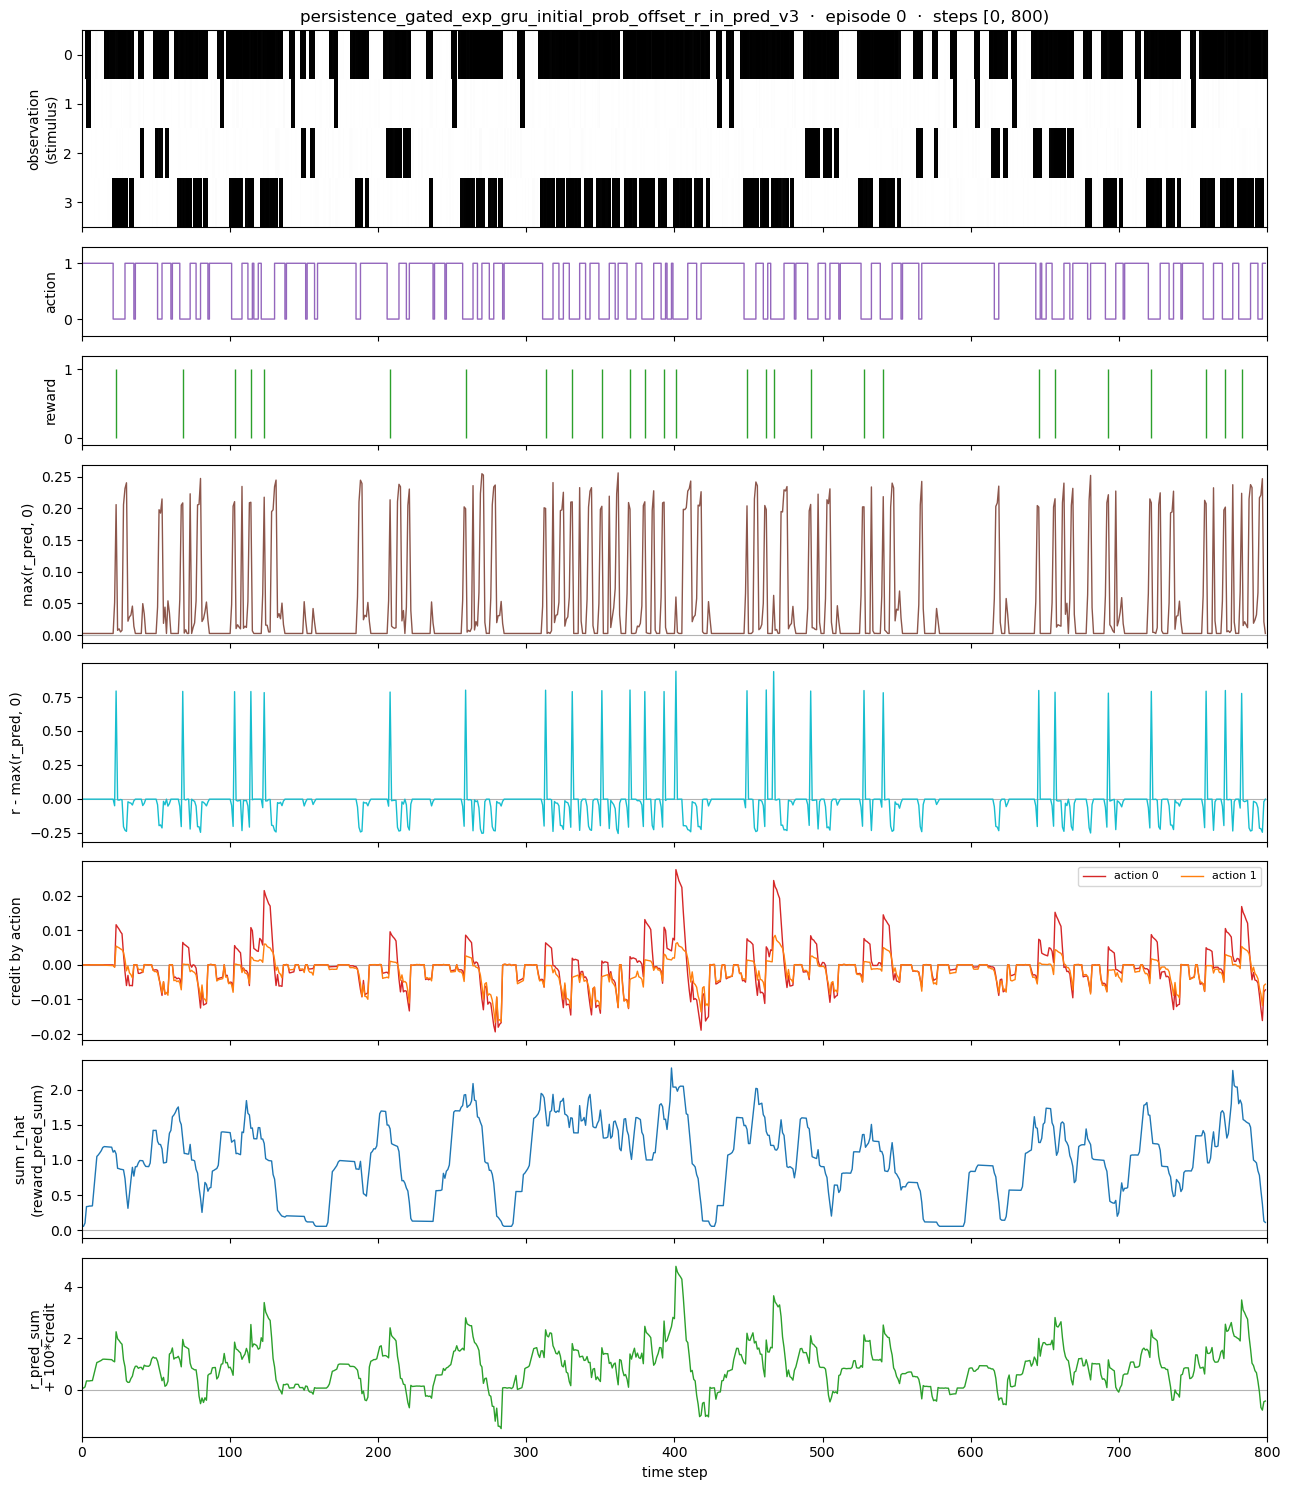

In [5]:
T0, T1 = 0, min(800, T)          # time window to plot
t = np.arange(T0, T1)

fig, ax = plt.subplots(8, 1, sharex=True, figsize=(13, 15),
                       gridspec_kw={'height_ratios': [1.1, 0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0]})

# 1) observations (stimulus x time)
ax[0].imshow(obs[T0:T1].T, aspect='auto', cmap='Greys', vmin=0, vmax=1,
             extent=[T0, T1, OBS - 0.5, -0.5], interpolation='nearest')
ax[0].set_yticks(range(OBS)); ax[0].set_ylabel('observation\n(stimulus)')

# 2) action
ax[1].step(t, actions[T0:T1], where='post', color='tab:purple', lw=1)
ax[1].set_yticks([0, 1]); ax[1].set_ylim(-0.3, 1.3); ax[1].set_ylabel('action')

# 3) reward (spikes)
rt = t[rewards[T0:T1] > 0]
ax[2].vlines(rt, 0, 1, color='tab:green', lw=1)
ax[2].set_yticks([0, 1]); ax[2].set_ylim(-0.1, 1.2); ax[2].set_ylabel('reward')

# 4) relu'd reward prediction (baseline in the credit signal)
ax[3].axhline(0, color='0.7', lw=0.8)
ax[3].plot(t, r_pred_relu[T0:T1], color='tab:brown', lw=1)
ax[3].set_ylabel('max(r_pred, 0)')

# 5) reward - max(r_pred, 0)  (prediction-error part of the credit signal)
ax[4].axhline(0, color='0.7', lw=0.8)
ax[4].plot(t, rpe_relu[T0:T1], color='tab:cyan', lw=1)
ax[4].set_ylabel('r - max(r_pred, 0)')

# 6) credit of the current observation under each action, as two lines
ax[5].axhline(0, color='0.7', lw=0.8)
ax[5].plot(t, credit_by_action[T0:T1, 0], color='tab:red', lw=1, label='action 0')
ax[5].plot(t, credit_by_action[T0:T1, 1], color='tab:orange', lw=1, label='action 1')
ax[5].legend(loc='upper right', fontsize=8, ncol=2)
ax[5].set_ylabel('credit by action')

# 7) reward_pred_sum
ax[6].axhline(0, color='0.7', lw=0.8)
ax[6].plot(t, reward_pred_sum[T0:T1], color='tab:blue', lw=1)
ax[6].set_ylabel('sum r_hat\n(reward_pred_sum)')

# 8) advantage (pre-standardization): reward_pred_sum + 100 * credit_for_action
ax[7].axhline(0, color='0.7', lw=0.8)
ax[7].plot(t, advantage_raw[T0:T1], color='tab:green', lw=1)
ax[7].set_ylabel('r_pred_sum\n+ 100*credit')
ax[7].set_xlabel('time step')

ax[0].set_title(f'{EXP}  ·  episode {TRAJ_IDX}  ·  steps [{T0}, {T1})')
plt.tight_layout()
plt.show()